In [ ]:
# Switch path to root of project
import os
os.environ["CUDA_VISIBLE_DEVICES"]="3"
current_dir = "/home/xxx/research/MedH/Mitigation/LVLMs"
# src_path = os.path.join(current_dir, 'src')
os.chdir(current_dir)

from open_clip import create_model_and_transforms, get_mean_std
from open_clip import HFTokenizer
from PIL import Image
import torch
from urllib.request import urlopen

# Define main parameters
model = 'ViT-B-16-quickgelu' # available pretrained weights ['ViT-L-14-336-quickgelu', 'ViT-B-16-quickgelu']
# pretrained = "/data/xxx/CLIP/unimed_clip_vit_l14_base_text_encoder.pt" # Path to pretrained weights
pretrained = "/data/xxx/CLIP/unimed_clip_vit_b16.pt"
text_encoder_name = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract" # available pretrained weights ["microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract", "microsoft/BiomedNLP-BiomedBERT-large-uncased-abstract"]
mean, std = get_mean_std()
device='cuda'

In [ ]:
model_med, _, preprocess = create_model_and_transforms(
    model,
    pretrained,
    precision='amp',
    device=device,
    force_quick_gelu=True,
    pretrained_image=False,
    mean=mean, std=std,
    inmem=True,
    text_encoder_name=text_encoder_name,
)
tokenizer = HFTokenizer(
    text_encoder_name,
    context_length=256,
    **{},
)

In [3]:
model_visual_encoder = model_med.visual.cuda()
model_text_encoder = model_med.text_encoder.cuda()

In [ ]:
# load abdomen vqa data
import json
# vqa_train_file = "/data/xxx/hallucination/CARES/IU_Xray/training.json"
# vqa_train_file = "/data/xxx/hallucination/CARES/OmniMedVQA/training_masks_top4.json"
# vqa_train_file = "/data/xxx/hallucination/PathVQA/pvqa/training_masks_top4.json"
# vqa_train_file = "/data/xxx/hallucination/Slake/data/training_masks_all.json"
# vqa_train_file = "/data/xxx/hallucination/VQA_RAD/data/training_masks_top4.json"

vqa_train_file = "/data/xxx/hallucination/IU_Xray/data_report/training.json"
# vqa_train_file = "/data/xxx/hallucination/MIMIC_CXR/data_report/training.json"

with open(vqa_train_file, "r") as f:
    vqa_data = json.load(f)
# Check the loaded data
print(f"Loaded {len(vqa_data)} vqa data")
# filter only english data
vqa_data_train = vqa_data
print(f"Filtered {len(vqa_data_train)} vqa data")

Loaded 2069 vqa data
Filtered 2069 vqa data


In [ ]:
# sample images
import os
import random
from pathlib import Path

from sklearn.manifold import TSNE
import numpy as np

import matplotlib.pyplot as plt

# Step 1: Locate all `source.jpg` files in subfolders
# root_dir = Path("/data/xxx/hallucination/IU_Xray/iu_xray/images")
# root_dir = Path("/data/xxx/hallucination/OmniMedVQA/VQA/raw/OmniMedVQA")
# root_dir = Path("/data/xxx/hallucination/PathVQA/pvqa/images/train")
# root_dir = Path("/data/xxx/hallucination/Slake/imgs")
# root_dir = Path("/data/xxx/hallucination/VQA_RAD/images/")
# image_paths = list(root_dir.rglob("source.jpg"))

root_dir = Path("/data/xxx/hallucination/IU_Xray/iu_xray/images")
# root_dir = Path("/data/xxx/hallucination/MIMIC_CXR/sampled_files_train")

image_paths = list(set([i['image'] for i in vqa_data_train]))

# Step 2: Randomly sample 100 images
sampled_paths = image_paths

print(f"Found {len(image_paths)} training images, sampled {len(sampled_paths)}")

Found 2069 training images, sampled 2069


In [8]:
full_sampled_paths = []
for path in sampled_paths:
    full_path = os.path.join(root_dir, path)
    full_sampled_paths.append(full_path)

In [9]:
import torch.nn.functional as F
from tqdm import tqdm

In [10]:
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
from tqdm import tqdm

feature_cos_matrix = []
start_index, sample_number = 0, len(sampled_paths)
ind = 0
cos_matrix_dict = {}

for img_path in tqdm(full_sampled_paths[start_index:start_index + sample_number]):
    relative_path = sampled_paths[ind]
    ind += 1
    inputs = preprocess(Image.open(img_path)).to("cuda").unsqueeze(0)

    with torch.no_grad():
        vision_output = model_visual_encoder.forward_intermediates(inputs)
        patch_tokens = vision_output['image_intermediates'][-1][:, 1:, :].squeeze(0)  # [196, D]
        patch_tokens = F.normalize(patch_tokens, dim=1)  # [196, D]

        # STEP 1: Reshape from [196, D] to [14, 14, D]
        patch_H, patch_W = 14, 14  # original grid
        D = patch_tokens.shape[1]
        patch_tokens_2d = patch_tokens.view(patch_H, patch_W, D).permute(2, 0, 1).unsqueeze(0)  # [1, D, 14, 14]

        # STEP 2: Interpolate to [24, 24]
        upsampled = F.interpolate(patch_tokens_2d, size=(24, 24), mode='bilinear', align_corners=False)  # [1, D, 24, 24]

        # STEP 3: Flatten to [576, D]
        patch_tokens_up = upsampled.squeeze(0).permute(1, 2, 0).reshape(-1, D)  # [576, D]
        patch_tokens_up = F.normalize(patch_tokens_up, dim=1)  # Normalize again

        # STEP 4: Compute cosine similarity
        cos_sim_up = patch_tokens_up @ patch_tokens_up.T  # [576, 576]

        # Store result
        feature_cos_matrix.append(cos_sim_up.cpu())
        cos_matrix_dict[relative_path] = cos_sim_up.cpu().numpy()


100%|██████████| 2069/2069 [00:33<00:00, 62.55it/s]


In [ ]:
# save cosine similarity matrix
import pickle
# save_root_path = "/data/xxx/hallucination/CARES/IU_Xray/steering_data_base/"
# save_root_path = "/data/xxx/hallucination/CARES/OmniMedVQA/steering_data_base/"
# save_root_path = "/data/xxx/hallucination/PathVQA/pvqa/steering_data_base/"
# save_root_path = "/data/xxx/hallucination/Slake/steering/steer_data_base/"
# save_root_path = "/data/xxx/hallucination/VQA_RAD/steering/steer_data_base/"

save_root_path = "/data/xxx/hallucination/IU_Xray/data_report/steering_data_base/"
# save_root_path = "/data/xxx/hallucination/MIMIC_CXR/data_report/steering_data_base/"

if not os.path.exists(save_root_path):
    os.makedirs(save_root_path)
# save cosine similarity matrix
with open(save_root_path + "cosine_matrix_dict.pkl", "wb") as f:
    pickle.dump(cos_matrix_dict, f)

(-0.5, 575.5, 575.5, -0.5)

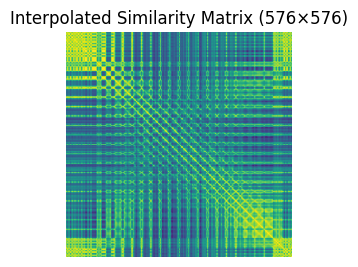

In [28]:
example_interpolated = cos_matrix_dict['xmlab293/source.jpg']

plt.subplot(1, 2, 1)
plt.imshow(example_interpolated, cmap='viridis')
plt.title("Interpolated Similarity Matrix (576×576)")
plt.axis('off')


(-0.5, 575.5, 575.5, -0.5)

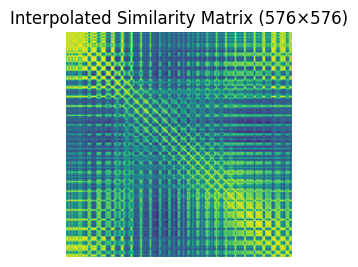

In [38]:
example_interpolated = cos_matrix_dict['synpic28210.jpg']

plt.subplot(1, 2, 1)
plt.imshow(example_interpolated, cmap='viridis')
plt.title("Interpolated Similarity Matrix (576×576)")
plt.axis('off')
